#📌 Extracción

In [43]:
import pandas as pd

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

df = pd.read_json(url)

df = pd.json_normalize(df.to_dict(orient="records"))

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [44]:
df.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [46]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


#🔧 Transformación

In [47]:
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

In [48]:
df["Cuentas_Diarias"] = df["account.Charges.Monthly"] / 30

In [49]:
df.duplicated().sum()
df.head(21)

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40,2.796667
5,0013-MHZWF,No,Female,0,No,Yes,9,Yes,No,DSL,...,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),69.40,571.45,2.313333
6,0013-SMEOE,No,Female,1,Yes,No,71,Yes,No,Fiber optic,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),109.70,7904.25,3.656667
7,0014-BMAQU,No,Male,0,Yes,No,63,Yes,Yes,Fiber optic,...,No,Yes,No,No,Two year,Yes,Credit card (automatic),84.65,5377.80,2.821667
8,0015-UOCOJ,No,Female,1,No,No,7,Yes,No,DSL,...,No,No,No,No,Month-to-month,Yes,Electronic check,48.20,340.35,1.606667
9,0016-QLJIS,No,Female,0,Yes,Yes,65,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,Two year,Yes,Mailed check,90.45,5957.90,3.015000


In [50]:
df.rename(columns={
    "customerID": "ID_Cliente",
    "Churn": "Abandono",
    "customer.gender": "Genero",
    "customer.SeniorCitizen": "AdultoMayor",
    "customer.Partner": "TienePareja",
    "customer.Dependents": "Dependientes",
    "customer.tenure": "MesesCliente",
    "phone.PhoneService": "ServicioTelefono",
    "phone.MultipleLines": "MultiplesLineas",
    "internet.InternetService": "ServicioInternet",
    "internet.OnlineSecurity": "SeguridadOnline",
    "internet.OnlineBackup": "BackupOnline",
    "internet.DeviceProtection": "ProteccionDispositivo",
    "internet.TechSupport": "SoporteTecnico",
    "internet.StreamingTV": "StreamingTV",
    "internet.StreamingMovies": "StreamingPeliculas",
    "account.Contract": "TipoContrato",
    "account.PaperlessBilling": "FacturaDigital",
    "account.PaymentMethod": "MetodoPago",
    "account.Charges.Monthly": "CargoMensual",
    "account.Charges.Total": "CargoTotal"
}, inplace=True)

In [51]:
df.replace({
    "Female": "Mujer",
    "Male": "Hombre",
    "Month-to-month": "Mensual",
    "One year": "Un año",
    "Two year": "Dos años",
    "Electronic check": "Cheque electrónico",
    "Mailed check": "Cheque por correo",
    "Bank transfer (automatic)": "Transferencia bancaria",
    "Credit card (automatic)": "Tarjeta de crédito"
}, inplace=True)

In [52]:
df.head(21)

,ID_Cliente,Abandono,Genero,AdultoMayor,TienePareja,Dependientes,MesesCliente,ServicioTelefono,MultiplesLineas,ServicioInternet,...,ProteccionDispositivo,SoporteTecnico,StreamingTV,StreamingPeliculas,TipoContrato,FacturaDigital,MetodoPago,CargoMensual,CargoTotal,Cuentas_Diarias
0,0002-ORFBO,No,Mujer,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,Un año,Yes,Cheque por correo,65.60,593.30,2.186667
1,0003-MKNFE,No,Hombre,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Mensual,No,Cheque por correo,59.90,542.40,1.996667
2,0004-TLHLJ,Yes,Hombre,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Mensual,Yes,Cheque electrónico,73.90,280.85,2.463333
3,0011-IGKFF,Yes,Hombre,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Mensual,Yes,Cheque electrónico,98.00,1237.85,3.266667
4,0013-EXCHZ,Yes,Mujer,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Mensual,Yes,Cheque por correo,83.90,267.40,2.796667
5,0013-MHZWF,No,Mujer,0,No,Yes,9,Yes,No,DSL,...,No,Yes,Yes,Yes,Mensual,Yes,Tarjeta de crédito,69.40,571.45,2.313333
6,0013-SMEOE,No,Mujer,1,Yes,No,71,Yes,No,Fiber optic,...,Yes,Yes,Yes,Yes,Dos años,Yes,Transferencia bancaria,109.70,7904.25,3.656667
7,0014-BMAQU,No,Hombre,0,Yes,No,63,Yes,Yes,Fiber optic,...,No,Yes,No,No,Dos años,Yes,Tarjeta de crédito,84.65,5377.80,2.821667
8,0015-UOCOJ,No,Mujer,1,No,No,7,Yes,No,DSL,...,No,No,No,No,Mensual,Yes,Cheque electrónico,48.20,340.35,1.606667
9,0016-QLJIS,No,Mujer,0,Yes,Yes,65,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,Dos años,Yes,Cheque por correo,90.45,5957.90,3.015000


#📊 Carga y análisis

In [53]:
df.describe()

,AdultoMayor,MesesCliente,CargoMensual,CargoTotal,Cuentas_Diarias
count,7267.000000,7267.000000,7267.000000,7256.000000,7267.000000
mean,0.162653,32.346498,64.720098,2280.634213,2.157337
std,0.369074,24.571773,30.129572,2268.632997,1.004319
min,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,9.000000,35.425000,400.225000,1.180833
50%,0.000000,29.000000,70.300000,1391.000000,2.343333
75%,0.000000,55.000000,89.875000,3785.300000,2.995833
max,1.000000,72.000000,118.750000,8684.800000,3.958333


In [54]:
df.median(numeric_only=True)

,0
AdultoMayor,0.000000
MesesCliente,29.000000
CargoMensual,70.300000
CargoTotal,1391.000000
Cuentas_Diarias,2.343333


In [55]:
df.std(numeric_only=True)

,0
AdultoMayor,0.369074
MesesCliente,24.571773
CargoMensual,30.129572
CargoTotal,2268.632997
Cuentas_Diarias,1.004319


In [56]:
df["Abandono"].value_counts()

,count
Abandono,
No,5174
Yes,1869
,224


<Axes: title={'center': 'Distribución de Abandono'}, xlabel='Abandono'>

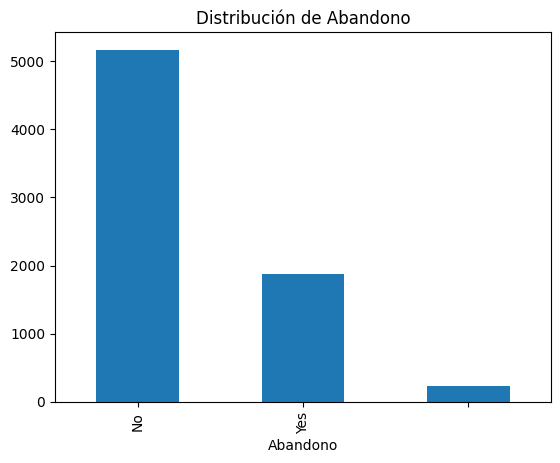

In [57]:
df["Abandono"].value_counts().plot(kind="bar", title="Distribución de Abandono")

In [58]:
for col in df.columns:
    print(col)

ID_Cliente
Abandono
Genero
AdultoMayor
TienePareja
Dependientes
MesesCliente
ServicioTelefono
MultiplesLineas
ServicioInternet
SeguridadOnline
BackupOnline
ProteccionDispositivo
SoporteTecnico
StreamingTV
StreamingPeliculas
TipoContrato
FacturaDigital
MetodoPago
CargoMensual
CargoTotal
Cuentas_Diarias


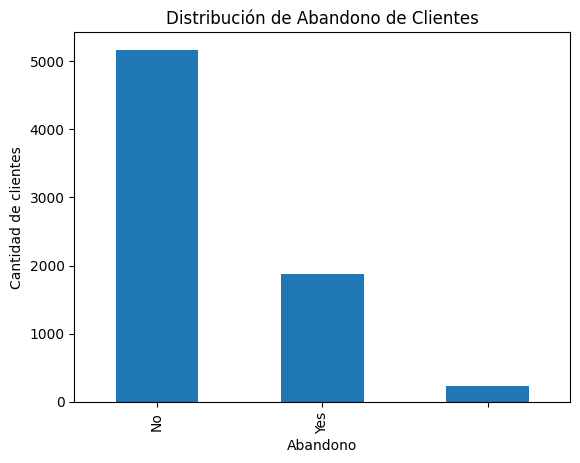

In [59]:
import matplotlib.pyplot as plt

df["Abandono"].value_counts().plot(
    kind="bar",
    title="Distribución de Abandono de Clientes"
)

plt.xlabel("Abandono")
plt.ylabel("Cantidad de clientes")
plt.show()

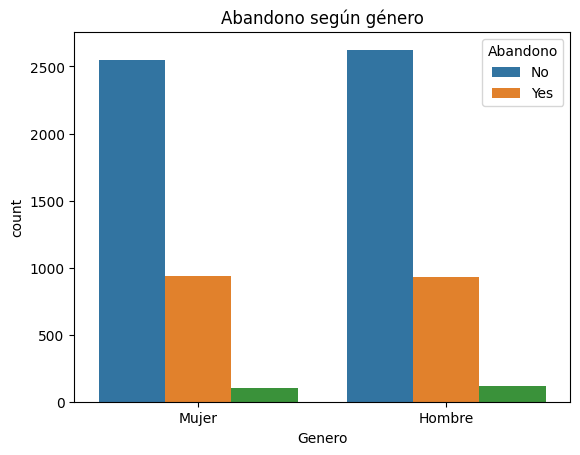

In [60]:
import seaborn as sns

sns.countplot(x="Genero", hue="Abandono", data=df)

plt.title("Abandono según género")
plt.show()

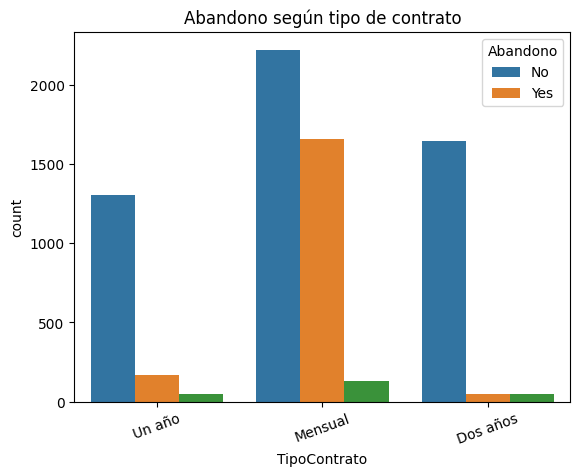

In [61]:
sns.countplot(x="TipoContrato", hue="Abandono", data=df)

plt.title("Abandono según tipo de contrato")
plt.xticks(rotation=20)
plt.show()

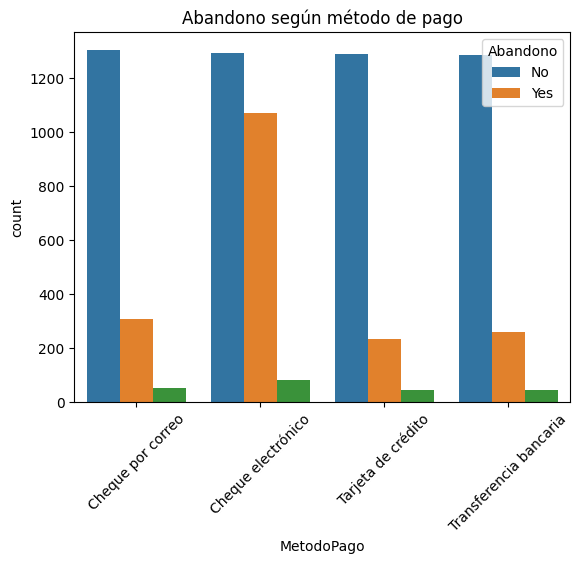

In [62]:
sns.countplot(x="MetodoPago", hue="Abandono", data=df)

plt.title("Abandono según método de pago")
plt.xticks(rotation=45)
plt.show()

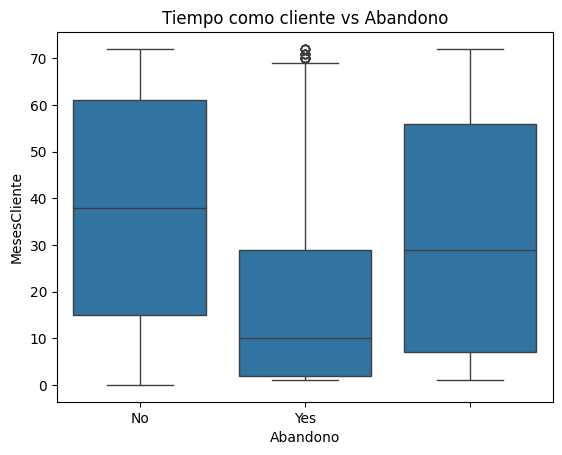

In [63]:
sns.boxplot(x="Abandono", y="MesesCliente", data=df)

plt.title("Tiempo como cliente vs Abandono")
plt.show()

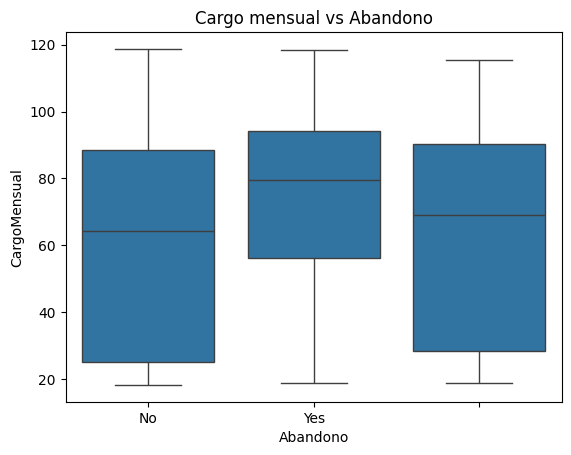

In [64]:
sns.boxplot(x="Abandono", y="CargoMensual", data=df)

plt.title("Cargo mensual vs Abandono")
plt.show()

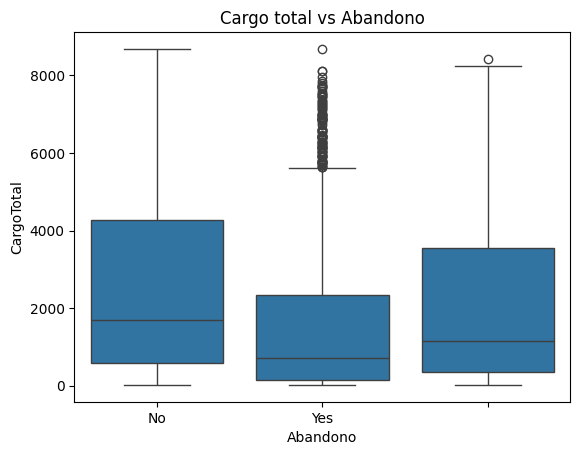

In [65]:
sns.boxplot(x="Abandono", y="CargoTotal", data=df)

plt.title("Cargo total vs Abandono")
plt.show()

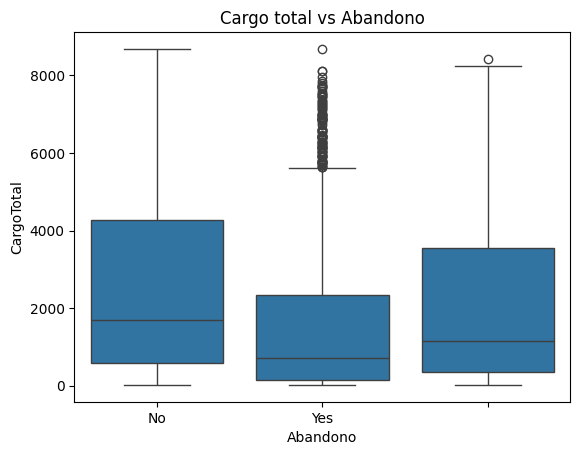

In [66]:
sns.boxplot(x="Abandono", y="CargoTotal", data=df)

plt.title("Cargo total vs Abandono")
plt.show()

#📄Informe final

**Introducción**
El fin de este análisis es comprender los factores asociados con la evasión de clientes (Abandono) en TelecomX
La evasión de cleintes representa un desafío importante para las empresas de telecomunicaicones, ya que la perdida de clientes puede impactar negativamente en los ingresos y estabilidad del negocio

**Limpieza y Tratamiento de Datos**
Los datos fueron obtenidos desde una API en formato JSON y cargados en un DataFrame utilizando **Pandas**.
Durante esta etapa exploré la estructura del dataset, verifiqué valores nulos y duplicados, y convertí algunas columnas al tipo de dato correcto. También renombré las columnas al español para facilitar su interpretación.
Finalmente, creé una nueva variable llamada **Cuentas_Diarias**, calculada a partir del cargo mensual dividido entre 30 días.

**Análisis Exploratorio de Datos**
Realicé un análisis descriptivo de las variables numéricas para entender mejor su distribución, calculando métricas como media, mediana y desviación estándar.
Luego analicé la relación entre la variable **Abandono** y algunas variables categóricas y numéricas utilizando gráficos. Entre ellas se analizaron **género, tipo de contrato y método de pago**, así como variables numéricas como **MesesCliente, CargoMensual y CargoTotal**.
Estas visualizaciones me permitieron observar algunos patrones en el comportamiento de los clientes.

**Conclusiones e Insights**
A partir del análisis observé que los clientes con **contratos mensuales** parecen tener mayor tendencia a cancelar el servicio. También se observa que los clientes con **menos tiempo en la empresa** presentan más casos de abandono.
Además, algunos **métodos de pago** y **cargos mensuales más altos** parecen estar asociados con una mayor probabilidad de cancelación.

**Recomendaciones**
Con base en estos resultados, algunas posibles acciones serían promover **contratos de mayor duración** y desarrollar **estrategias de fidelización para clientes nuevos**.
También podría ser útil analizar con más detalle a los clientes con **mayores cargos mensuales y menor tiempo en la empresa** para implementar acciones que ayuden a reducir la evasión.